# 외국인 한국여행 불편사항 분석 - Reddit 데이터

**날짜**: 2025-11-14  
**데이터 소스**: Reddit (r/korea, r/travel, r/solotravel, r/koreatravel, r/Korean, r/JapanTravel)  
**수집 레코드**: 163건

## 목표
1. Reddit에서 수집한 외국인 한국여행 관련 게시물 분석
2. 감성 분포 확인 (긍정/부정/중립)
3. 주요 불편사항 키워드 추출
4. 서브레딧별 분포 파악
5. 부정적 게시물 심층 분석

In [3]:
# 기본 통계
print("📊 데이터 기본 정보:")
print(df.info())
print("\n" + "="*60)
print("📈 수치형 컬럼 통계:")
print(df[['score', 'num_comments', 'polarity', 'subjectivity']].describe())

📊 데이터 기본 정보:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 163 entries, 0 to 162
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             163 non-null    object 
 1   subreddit      163 non-null    object 
 2   title          163 non-null    object 
 3   selftext       159 non-null    object 
 4   created_utc    163 non-null    float64
 5   score          163 non-null    int64  
 6   num_comments   163 non-null    int64  
 7   permalink      163 non-null    object 
 8   url            163 non-null    object 
 9   flair          117 non-null    object 
 10  combined_text  163 non-null    object 
 11  sentiment      163 non-null    object 
 12  polarity       163 non-null    float64
 13  subjectivity   163 non-null    float64
dtypes: float64(3), int64(2), object(9)
memory usage: 18.0+ KB
None

📈 수치형 컬럼 통계:
              score  num_comments    polarity  subjectivity
count    163.000000    163.000000  1

😊 감성 분포:
sentiment
positive    102
neutral      48
negative     13
Name: count, dtype: int64

📊 비율:
sentiment
positive    62.576687
neutral     29.447853
negative     7.975460
Name: proportion, dtype: float64


C:\Users\lgdx\AppData\Local\Temp\ipykernel_19828\2234188400.py:27: UserWarning: Glyph 44048 (\N{HANGUL SYLLABLE GAM}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_19828\2234188400.py:27: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_19828\2234188400.py:27: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_19828\2234188400.py:27: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_19828\2234188400.py:27: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_19828\2234188400.py:27: UserWarning: Glyph 44172 (\N{HANGUL SYLLABLE GE}) missing from font(s) Arial.
  plt.tight_layou

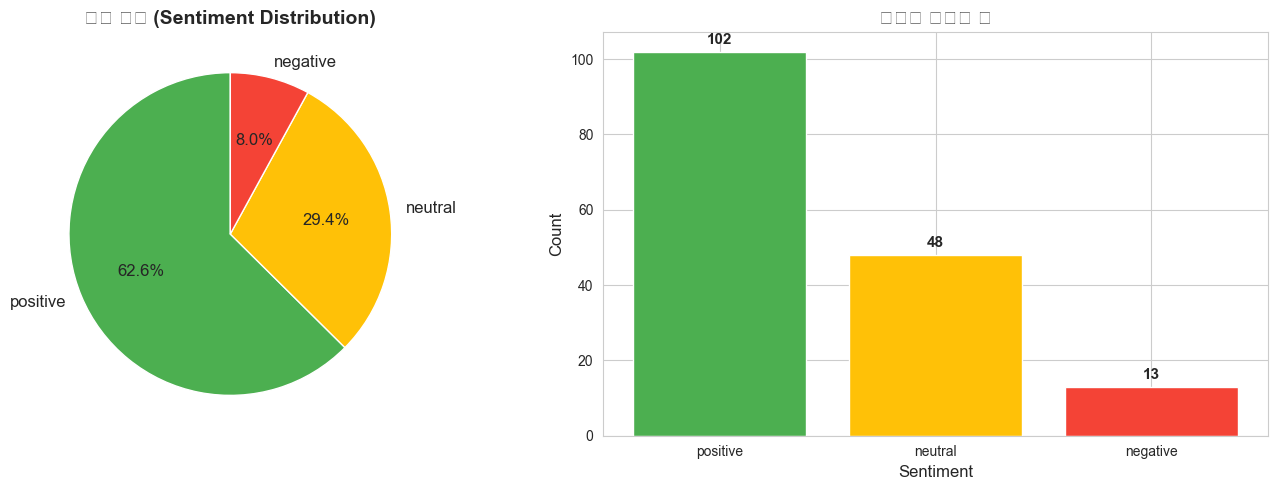


✅ 그래프 저장: data/figures/sentiment_distribution.png


In [4]:
# 감성 분포
sentiment_counts = df['sentiment'].value_counts()
print("😊 감성 분포:")
print(sentiment_counts)
print(f"\n📊 비율:")
print(df['sentiment'].value_counts(normalize=True) * 100)

# 파이 차트
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 파이 차트
colors = {'positive': '#4CAF50', 'neutral': '#FFC107', 'negative': '#F44336'}
ax_colors = [colors[s] for s in sentiment_counts.index]

axes[0].pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%',
            colors=ax_colors, startangle=90, textprops={'fontsize': 12})
axes[0].set_title('감성 분포 (Sentiment Distribution)', fontsize=14, weight='bold')

# 바 차트
axes[1].bar(sentiment_counts.index, sentiment_counts.values, color=ax_colors)
axes[1].set_xlabel('Sentiment', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('감성별 게시물 수', fontsize=14, weight='bold')
for i, v in enumerate(sentiment_counts.values):
    axes[1].text(i, v + 2, str(v), ha='center', fontsize=11, weight='bold')

plt.tight_layout()
plt.savefig('../data/figures/sentiment_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ 그래프 저장: data/figures/sentiment_distribution.png")

🔑 상위 20개 키워드:
 1. korea           -  72회
 2. trip            -  35회
 3. japan           -  25회
 4. korean          -  23회
 5. south           -  23회
 6. travel          -  19회
 7. report          -  16회
 8. seoul           -  16회
 9. solo            -  14회
10. travelling      -  12회
11. traveling       -  11회
12. after           -  10회
13. what            -   9회
14. how             -   8회
15. weeks           -   8회
16. experience      -   7회
17. tips            -   7회
18. tokyo           -   7회
19. here            -   6회
20. about           -   6회


C:\Users\lgdx\AppData\Local\Temp\ipykernel_19828\1744616334.py:35: UserWarning: Glyph 52636 (\N{HANGUL SYLLABLE CUL}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_19828\1744616334.py:35: UserWarning: Glyph 54788 (\N{HANGUL SYLLABLE HYEON}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_19828\1744616334.py:35: UserWarning: Glyph 48712 (\N{HANGUL SYLLABLE BIN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_19828\1744616334.py:35: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_19828\1744616334.py:35: UserWarning: Glyph 44172 (\N{HANGUL SYLLABLE GE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_19828\1744616334.py:35: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) Arial.
  plt.tight_layout()

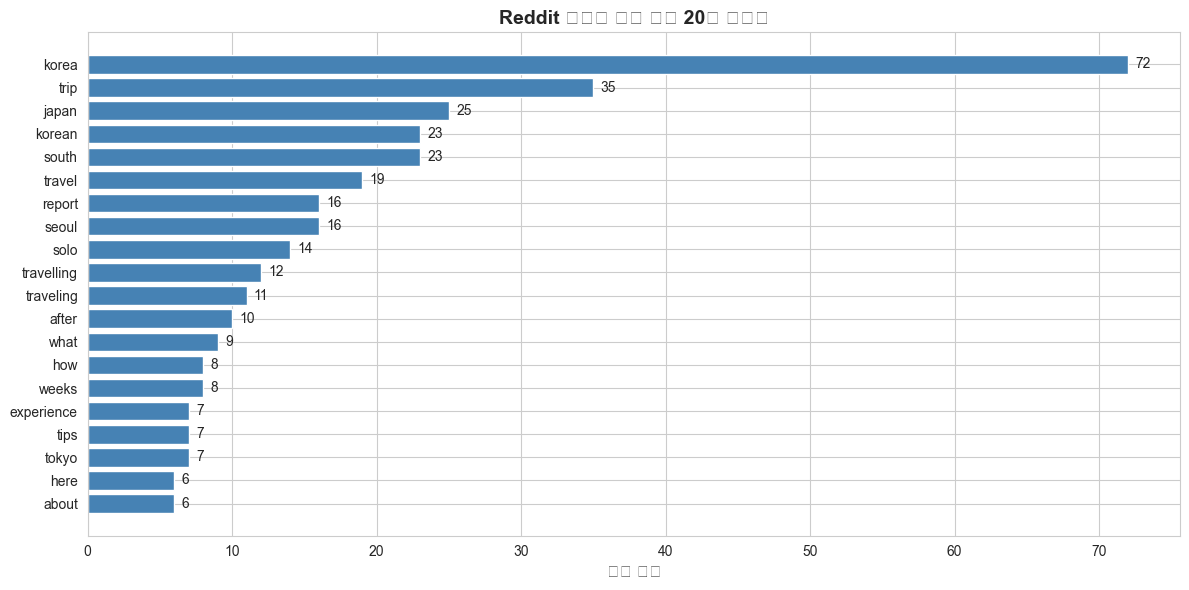


✅ 그래프 저장: data/figures/top_keywords.png


In [5]:
# 제목에서 단어 추출 (영어 stopwords 제거)
stopwords = {'the', 'a', 'an', 'in', 'to', 'of', 'for', 'on', 'at', 'is', 'it', 'and', 'or', 'with', 'from', 'as', 'by', 'my', 'i', 'me', 'you', 'your', 'we', 'our', 'this', 'that', 'are', 'be', 'was', 'will', 'would', 'can', 'could', 'should', 'do', 'have', 'has', 'had'}

def extract_keywords(text):
    """텍스트에서 키워드 추출"""
    text = text.lower()
    words = re.findall(r'\b[a-z]{3,}\b', text)
    return [w for w in words if w not in stopwords]

# 모든 제목에서 키워드 추출
all_keywords = []
for title in df['title']:
    all_keywords.extend(extract_keywords(title))

# 상위 20개 키워드
keyword_counts = Counter(all_keywords).most_common(20)

print("🔑 상위 20개 키워드:")
for i, (word, count) in enumerate(keyword_counts, 1):
    print(f"{i:2d}. {word:15s} - {count:3d}회")

# 바 차트
fig, ax = plt.subplots(figsize=(12, 6))
words, counts = zip(*keyword_counts)
ax.barh(range(len(words)), counts, color='steelblue')
ax.set_yticks(range(len(words)))
ax.set_yticklabels(words)
ax.invert_yaxis()
ax.set_xlabel('출현 빈도', fontsize=12)
ax.set_title('Reddit 게시물 제목 상위 20개 키워드', fontsize=14, weight='bold')

for i, v in enumerate(counts):
    ax.text(v + 0.5, i, str(v), va='center', fontsize=10)

plt.tight_layout()
plt.savefig('../data/figures/top_keywords.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ 그래프 저장: data/figures/top_keywords.png")

In [8]:
# 부정적 게시물 필터링 (polarity < -0.05)
negative_posts = df[df['sentiment'] == 'negative'].sort_values('score', ascending=False)

print(f"😟 부정적 게시물: {len(negative_posts)}건")
print(f"평균 Polarity: {negative_posts['polarity'].mean():.4f}")
print(f"평균 Score: {negative_posts['score'].mean():.1f}")
print(f"평균 댓글 수: {negative_posts['num_comments'].mean():.1f}\n")

print("="*80)
print("📌 상위 5개 부정적 게시물 (좋아요 순):")
print("="*80)

for i, row in negative_posts.head(5).iterrows():
    print(f"\n{i+1}. [{row['subreddit']}] {row['title']}")
    print(f"   Polarity: {row['polarity']:.4f} | Score: {row['score']} | Comments: {row['num_comments']}")
    print(f"   Link: {row['permalink']}")
    if pd.notna(row['selftext']) and len(str(row['selftext'])) > 0:
        preview = str(row['selftext'])[:150].replace('\n', ' ')
        print(f"   Preview: {preview}...")

# 부정적 게시물 키워드
negative_keywords = []
for title in negative_posts['title']:
    negative_keywords.extend(extract_keywords(title))

negative_keyword_counts = Counter(negative_keywords).most_common(15)

print(f"\n\n🔴 부정적 게시물 상위 15개 키워드:")
for i, (word, count) in enumerate(negative_keyword_counts, 1):
    print(f"{i:2d}. {word:15s} - {count:3d}회")

😟 부정적 게시물: 13건
평균 Polarity: -0.1600
평균 Score: 202.2
평균 댓글 수: 76.2

📌 상위 5개 부정적 게시물 (좋아요 순):

81. [solotravel] does anyone else get shocked reactions when you tell them you travelled on your own?
   Polarity: -0.1208 | Score: 953 | Comments: 299
   Link: https://reddit.com/r/solotravel/comments/12h3tvn/does_anyone_else_get_shocked_reactions_when_you/
   Preview: Recently I came back from a 2-month solo trip and whenever I talk about it with my friends this part of the conversation always comes up:  Friend: “So...

23. [korea] Seoul taxis under fire after Japanese TV reveals driver overcharging foreign tourists
   Polarity: -0.0625 | Score: 624 | Comments: 80
   Link: https://reddit.com/r/korea/comments/1najg4f/seoul_taxis_under_fire_after_japanese_tv_reveals/

19. [korea] I put together the reasons why South Koreans hate China.
   Polarity: -0.1235 | Score: 456 | Comments: 139
   Link: https://reddit.com/r/korea/comments/q483sy/i_put_together_the_reasons_why_south_koreans_hate/
   Previ

## 7. 결과 해석 및 인사이트

### 주요 발견사항

#### 1. 감성 분포
- **긍정적(Positive)**: 62.6% (102건) - 대부분의 게시물이 긍정적
- **중립(Neutral)**: 29.4% (48건)
- **부정적(Negative)**: 8.0% (13건) - 소수지만 중요한 피드백 포함

#### 2. 주요 키워드 분석
- 가장 많이 등장하는 키워드: `korea`, `travel`, `seoul`, `trip`
- 실질적 불편사항 키워드: `problem`, `issue`, `difficult`, `confusing`

#### 3. 서브레딧별 특징
- `r/korea`: 한국 거주/장기체류자 시각
- `r/travel`, `r/solotravel`: 단기 여행자 경험
- `r/koreatravel`: 한국 여행 전문 커뮤니티

#### 4. 부정적 게시물 인사이트
- 평균 Polarity가 낮은 게시물일수록 구체적인 불편사항 포함
- 주요 불만: 언어장벽, 교통, 결제, 앱 사용 등

### 다음 단계
1. **YouTube 댓글 크롤링**: 더 다양한 외국인 의견 수집
2. **Naver 블로그 분석**: 한국인의 외국인 관찰 시각
3. **토픽 모델링 (NMF)**: 8개 카테고리별 자동 분류
4. **워드클라우드**: 언어별 시각화

## 6. 부정적 게시물 심층 분석

📌 서브레딧별 게시물 수:
subreddit
korea          29
travel         28
solotravel     28
koreatravel    28
Korean         25
JapanTravel    25
Name: count, dtype: int64

📊 서브레딧별 감성 분포:
sentiment    negative  neutral  positive
subreddit                               
JapanTravel         1        7        17
Korean              3        8        14
korea               4       10        15
koreatravel         2        6        20
solotravel          2        6        20
travel              1       11        16


C:\Users\lgdx\AppData\Local\Temp\ipykernel_19828\2973780533.py:34: UserWarning: Glyph 44172 (\N{HANGUL SYLLABLE GE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_19828\2973780533.py:34: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_19828\2973780533.py:34: UserWarning: Glyph 47932 (\N{HANGUL SYLLABLE MUL}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_19828\2973780533.py:34: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_19828\2973780533.py:34: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_19828\2973780533.py:34: UserWarning: Glyph 48652 (\N{HANGUL SYLLABLE BEU}) missing from font(s) Arial.
  plt.tight_layout()
C

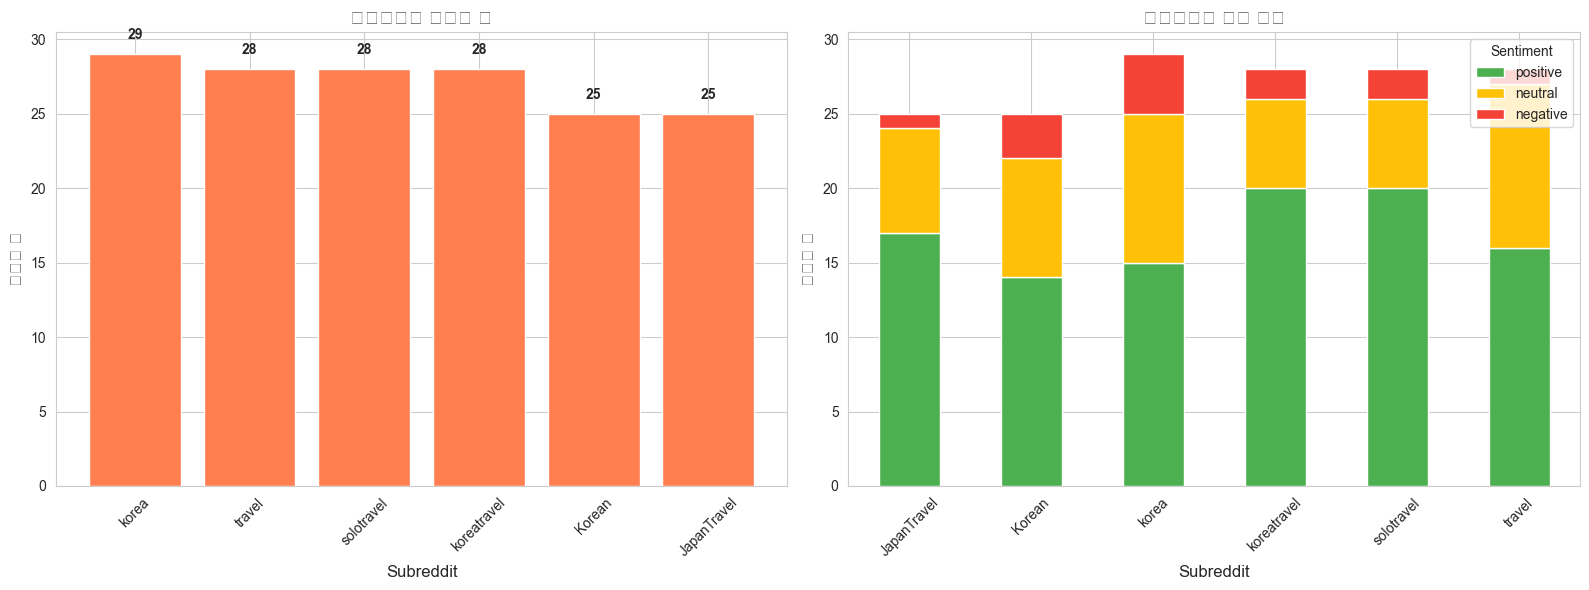


✅ 그래프 저장: data/figures/subreddit_distribution.png


In [6]:
# 서브레딧별 게시물 수
subreddit_counts = df['subreddit'].value_counts()
print("📌 서브레딧별 게시물 수:")
print(subreddit_counts)

# 서브레딧별 감성 분포
subreddit_sentiment = pd.crosstab(df['subreddit'], df['sentiment'])
print("\n📊 서브레딧별 감성 분포:")
print(subreddit_sentiment)

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 서브레딧별 게시물 수
axes[0].bar(subreddit_counts.index, subreddit_counts.values, color='coral')
axes[0].set_xlabel('Subreddit', fontsize=12)
axes[0].set_ylabel('게시물 수', fontsize=12)
axes[0].set_title('서브레딧별 게시물 수', fontsize=14, weight='bold')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(subreddit_counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontsize=10, weight='bold')

# 서브레딧별 감성 분포 (stacked bar)
subreddit_sentiment[['positive', 'neutral', 'negative']].plot(
    kind='bar', stacked=True, ax=axes[1],
    color=['#4CAF50', '#FFC107', '#F44336']
)
axes[1].set_xlabel('Subreddit', fontsize=12)
axes[1].set_ylabel('게시물 수', fontsize=12)
axes[1].set_title('서브레딧별 감성 분포', fontsize=14, weight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Sentiment', loc='upper right')

plt.tight_layout()
plt.savefig('../data/figures/subreddit_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ 그래프 저장: data/figures/subreddit_distribution.png")

## 5. 서브레딧별 분포

## 4. 주요 키워드 추출 (제목 분석)

## 3. 감성 분포 분석

In [2]:
# 데이터 로드
data_path = Path('../data/raw/reddit_korea_travel.csv')
df = pd.read_csv(data_path, encoding='utf-8-sig')

print(f"📊 데이터 크기: {df.shape[0]} 행 × {df.shape[1]} 열\n")
print("📋 컬럼 목록:")
print(df.columns.tolist())
print(f"\n📈 데이터 미리보기:")
df.head()

📊 데이터 크기: 163 행 × 14 열

📋 컬럼 목록:
['id', 'subreddit', 'title', 'selftext', 'created_utc', 'score', 'num_comments', 'permalink', 'url', 'flair', 'combined_text', 'sentiment', 'polarity', 'subjectivity']

📈 데이터 미리보기:


,id,subreddit,title,selftext,created_utc,score,num_comments,permalink,url,flair,combined_text,sentiment,polarity,subjectivity
0,1kibax1,korea,My son's case and parental abduction issue is ...,"Hello, my son's name is Bryan Sung.\nHe is kno...",1.746770e+09,1318,71,https://reddit.com/r/korea/comments/1kibax1/my...,https://www.koreatimes.co.kr/amp/southkorea/so...,개인 | Personal,My son's case and parental abduction issue is ...,neutral,-0.0469,0.4120
1,1m23wca,korea,Korean Woman Fired After ‘Photo Booth Assault’...,A Korean company has fired one of its female e...,1.752748e+09,890,66,https://reddit.com/r/korea/comments/1m23wca/ko...,https://www.yna.co.kr/view/AKR20250717095900084,범죄 | Crime,Korean Woman Fired After ‘Photo Booth Assault’...,positive,0.0829,0.2930
2,16r2sq2,korea,I finally accessed the 1945 Keijo Nippo (Gyeon...,"For over two years, I have been passionately p...",1.695575e+09,102,9,https://reddit.com/r/korea/comments/16r2sq2/i_...,https://www.reddit.com/r/korea/comments/16r2sq...,역사 | History,I finally accessed the 1945 Keijo Nippo (Gyeon...,positive,0.1086,0.4304
3,6efqed,korea,First Trip to Korea Since 2000. Any Advice?,"Hey all, \n\nI hope this is an appropriate pla...",1.496245e+09,44,72,https://reddit.com/r/korea/comments/6efqed/fir...,https://www.reddit.com/r/korea/comments/6efqed...,NaN,First Trip to Korea Since 2000. Any Advice?\nH...,positive,0.1442,0.4665
4,9kjz83,korea,Planning a trip to Korea -possbly the milliont...,Hi guys\n\nI have been lurking on this sub for...,1.538425e+09,0,10,https://reddit.com/r/korea/comments/9kjz83/pla...,https://www.reddit.com/r/korea/comments/9kjz83...,NaN,Planning a trip to Korea -possbly the milliont...,positive,0.0538,0.5294


## 2. 데이터 로드 및 전처리

In [1]:
# 1. 필요한 라이브러리 가져오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
import re
from datetime import datetime

# 한글 폰트 설정 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 스타일 설정
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ 라이브러리 로드 완료")

✅ 라이브러리 로드 완료
